In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

print("Libraries imported successfully")

✅ Libraries imported successfully


In [ ]:
demo_path = "../data/demo/demo_unseen_data.csv"

if not os.path.exists(demo_path):
    raise FileNotFoundError(f"Demo dataset not found at: {demo_path}")

demo_df = pd.read_csv(demo_path)
print("Demo dataset loaded successfully from:", demo_path)
print("Shape:", demo_df.shape)
demo_df.head()

✅ Demo dataset loaded successfully from: ../data/demo/demo_unseen_data.csv
Shape: (10, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,53131,0.000004,srp,-,INT,2,0,200,0,250000.000600,...,4,4,0,0,0,11,14,0,fuzzers,1
1,80323,0.815378,tcp,http,FIN,10,8,836,1094,20.849225,...,2,6,0,0,4,2,6,0,normal,0
2,55615,13.714951,tcp,-,FIN,8,6,364,268,0.947871,...,1,6,0,0,0,6,2,0,generic,1
3,67176,1.465845,tcp,ftp,FIN,12,12,2618,682,15.690609,...,1,2,0,0,0,3,2,0,normal,0
4,32652,4.029813,tcp,-,FIN,122,126,7816,16782,61.293170,...,1,1,0,0,0,1,9,0,normal,0


In [ ]:
import joblib


# Drop label column if present
if 'label' in demo_df.columns:
    demo_features = demo_df.drop(columns=['label'])
else:
    demo_features = demo_df.copy()

# One-hot encode categorical variables
demo_encoded = pd.get_dummies(demo_features, drop_first=True)

# Load training column structure
columns_path = "../data/processed/X_columns.csv"
if os.path.exists(columns_path):
    X_cols = pd.read_csv(columns_path)
    X_cols_list = X_cols['columns'].tolist()
    demo_encoded = demo_encoded.reindex(columns=X_cols_list, fill_value=0)
    print(f"✅ Loaded training column reference ({len(X_cols_list)} columns)")
else:
    print("⚠️ Training column reference not found. Using available columns only.")

# ✅ Load the same scaler used during training
scaler_path = "../models/scaler.pkl"
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print("✅ Loaded trained scaler for consistent preprocessing.")
else:
    scaler = StandardScaler()
    print("⚠️ Scaler not found. Using new one (may differ from training).")

# Apply scaling
demo_scaled = scaler.transform(demo_encoded)

print("✅ Demo data preprocessed successfully.")
print("Final encoded shape:", demo_scaled.shape)


✅ Loaded training column reference (197 columns)
✅ Loaded trained scaler for consistent preprocessing.
✅ Demo data preprocessed successfully.
Final encoded shape: (10, 197)


In [4]:
import torch
import torch.nn as nn
import os

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, num_layers=2):
        super(TransformerClassifier, self).__init__()
        # Must match the architecture from training (03_transformer.ipynb)
        self.embedding = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.classifier(x)
        return self.sigmoid(x)

# Initialize model using correct input dimension
input_dim = demo_scaled.shape[1]
model = TransformerClassifier(input_dim)

# Load trained model weights
model_path = "../models/transformer_model.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    print("✅ Transformer model loaded successfully from:", model_path)
else:
    print("⚠️ Model file not found. Please verify the path or filename.")

model.eval()


✅ Transformer model loaded successfully from: ../models/transformer_model.pth


C:\Users\91801\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TransformerClassifier(
  (embedding): Linear(in_features=197, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)

In [5]:
import numpy as np
import pandas as pd

# Convert to tensor
with torch.no_grad():
    inputs = torch.tensor(demo_scaled, dtype=torch.float32)
    preds = model(inputs).squeeze().numpy()

# Store predictions in a DataFrame
results = pd.DataFrame({
    "Anomaly_Score": preds,
    "Prediction": ["Attack" if p > 0.5 else "Normal" for p in preds]
})

print("✅ Predictions generated successfully")
print("\nSample Predictions:")
display(results.head(10))


✅ Predictions generated successfully

Sample Predictions:


,Anomaly_Score,Prediction
0,0.999989,Attack
1,0.000010,Normal
2,0.999985,Attack
3,0.000009,Normal
4,0.000006,Normal
5,0.000008,Normal
6,0.998981,Attack
7,0.999973,Attack
8,0.999986,Attack
9,0.000007,Normal


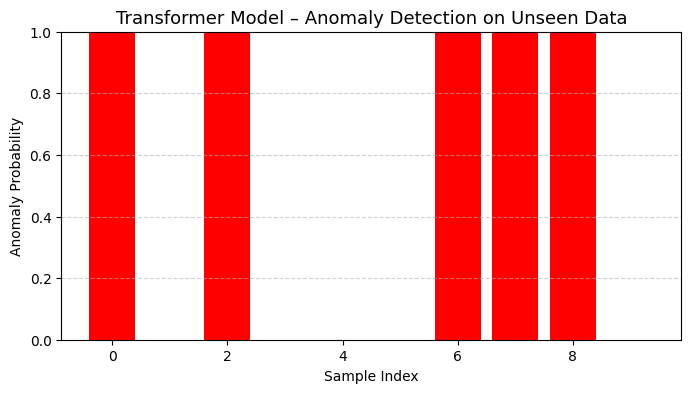

✅ Visualization completed successfully


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
colors = ['red' if p > 0.5 else 'green' for p in preds]
plt.bar(range(len(preds)), preds, color=colors)
plt.title("Transformer Model – Anomaly Detection on Unseen Data", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Anomaly Probability")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("✅ Visualization completed successfully")

In [7]:
# --- Test cell: Force one normal-like record ---
import numpy as np

# Create one "normal" record by reusing mean of demo data
normal_like = np.mean(demo_scaled, axis=0).reshape(1, -1)

# Predict anomaly score
with torch.no_grad():
    normal_pred = model(torch.tensor(normal_like, dtype=torch.float32)).item()

print(f"Normal-like record anomaly score: {normal_pred:.4f}")
if normal_pred <= 0.5:
    print("✅ Correct: Model recognizes it as normal (green).")
else:
    print("⚠️ Model still sees it as anomaly (likely because synthetic data differs from training distribution).")


Normal-like record anomaly score: 0.0000
✅ Correct: Model recognizes it as normal (green).
